<a href="https://colab.research.google.com/github/Gsmovidic/Entregable-1-Analisis-de-datos/blob/main/BD_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
train_dir= path = "/content/drive/MyDrive/Crack detection/Train images"

##1️ Base de Datos 1 – Dataset de Imágenes de Rotura del Suelo
 Fuente y tipo de datos
Fuente:  Secundaria, esta proviene de zenodo.
Link de la fuente: https://zenodo.org/records/11625820

Tipo de datos: Imágenes.

Formato: JPG / PNG.

Estructura: Organización en carpetas por clase:

Rotura grande

Rotura media

Rotura baja

No rotura

In [3]:
import os
os.listdir(train_dir)

['Train-high crack', 'Train-medium crack', 'Train-no crack', 'Train-low crack']

In [6]:

from PIL import Image



total_images = 0
class_counts = {}
image_sizes = []
total_size_bytes = 0
formats = set()

for class_name in os.listdir(path):
    class_path = os.path.join(path, class_name)

    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        class_counts[class_name] = len(images)
        total_images += len(images)

        for img_name in images:
            img_path = os.path.join(class_path, img_name)

            # Tamaño en disco
            total_size_bytes += os.path.getsize(img_path)

            try:
                with Image.open(img_path) as img:
                    image_sizes.append(img.size)  # (width, height)
                    formats.add(img.format)
            except:
                print(f"Error leyendo {img_path}")


num_classes = len(class_counts)
avg_width = np.mean([size[0] for size in image_sizes])
avg_height = np.mean([size[1] for size in image_sizes])
total_size_mb = total_size_bytes / (1024 * 1024)

print("Número total de imágenes:", total_images)
print("Número de clases:", num_classes)
print("Imágenes por clase:", class_counts)
print("Resolución promedio:", (round(avg_width), round(avg_height)))
print("Tamaño total del dataset (MB):", round(total_size_mb, 2))
print("Formatos encontrados:", formats)

Número total de imágenes: 1855
Número de clases: 4
Imágenes por clase: {'Train-high crack': 485, 'Train-medium crack': 499, 'Train-no crack': 371, 'Train-low crack': 500}
Resolución promedio: (640, 480)
Tamaño total del dataset (MB): 729.58
Formatos encontrados: {'PNG'}




 Posibles aplicaciones

Modelos de clasificación con CNN.

Sistemas de inspección automática de suelos.

Detección preventiva de daños estructurales.

Aplicaciones en ingeniería civil y mantenimiento predictivo.


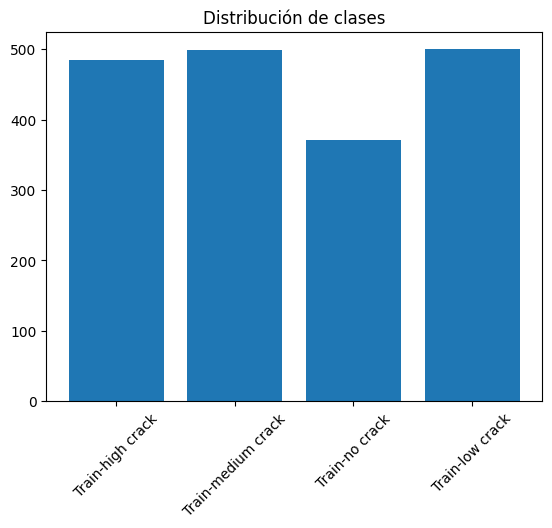

In [7]:


plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Distribución de clases")
plt.show()